# Neuron Reconstruction Pipeline Demo

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import collections
import tifffile as tif
import numpy as np

from neurotrack.inference import runtime
from neurotrack.core.pipeline_config import load_pipeline_config, PostprocessConfig
from neurotrack.inference.postprocess import process_results, write_processed_swc
from neurotrack.evaluation.io import (
    compute_pipeline_summary,
    evaluate_postprocessed_results,
    save_evaluation_results,
)

## Follow the instructions in the README to download the required data for this demo

## Make subsets of the full dataset to reduce the processing time for this example.

In [2]:
import shutil
# get the first five files from the image directory and the corresponding SWC files
# copy them to new directories 'gold166_tifs_cropped_subset' and 'gold166_swcs_cropped_subset'
img_dir = Path("../neurotrack_data/gold166_tifs_cropped")
swc_dir = Path("../neurotrack_data/gold166_swcs_cropped")
img_subset_dir = Path("../neurotrack_data/gold166_tifs_cropped_subset")
swc_subset_dir = Path("../neurotrack_data/gold166_swcs_cropped_subset")
img_subset_dir.mkdir(exist_ok=True)
swc_subset_dir.mkdir(exist_ok=True)

for img_file in list(img_dir.glob("*.tif"))[:4]:
    shutil.copy(img_file, img_subset_dir / img_file.name)
    swc_file = swc_dir / (img_file.stem + ".swc")
    if swc_file.exists():
        shutil.copy(swc_file, swc_subset_dir / swc_file.name)

# Load the inference and evaluation pipeline config

In [11]:
config_path = "../configs/inference/test_example_inference.json"

config = load_pipeline_config(config_path)
out_dir = Path("test_trace_inference_output")


## 1) Run Inference

In [4]:
# This will take several minutes if `seed_jitter_count` in the config is large.
inference_payload = runtime.run_inference(config, out_dir=out_dir)

print(f"Inference outputs: {inference_payload.keys()}")

# Most inference output values are not applicable for an inference run. Many stats are used during model training to evaluate terminal point classification accuracy.
# Others, like mean/max/min step variance and estimated returns are only applicable for Soft Actor Critic training.
print(f"'results' keys:")
for k in inference_payload['results'][0].keys():
    print(k)

Tracing:   0%|          | 0/4 [00:00<?, ?img/s, 091204c2]

Tracing: 100%|██████████| 4/4 [01:25<00:00, 21.33s/img, GMR_57C10_AD_01-Two_recombinase_flipouts_A-m-A-20111004_3_E2-left_optic_lobe.v3draw.extract_0]

Inference outputs: dict_keys(['results', 'run_out_dir'])
'results' keys:
neuron_name
labeled_neuron
paths
timing_ms
estimated_returns
mean_step_variance
max_step_variance
min_step_variance
mean_step_magnitude
max_step_magnitude
min_step_magnitude
choose_stop_count
choose_stop_with_target_count
false_choose_stop_count
false_choose_stop_rate
choose_stop_target_distance_mean
terminal_state_mean_step_magnitude
nonterminal_state_mean_step_magnitude
action_norm_separation
terminal_state_action_norm_histogram
nonterminal_state_action_norm_histogram
terminal_target_norm_threshold
false_stop_distance_threshold


### Plot the results

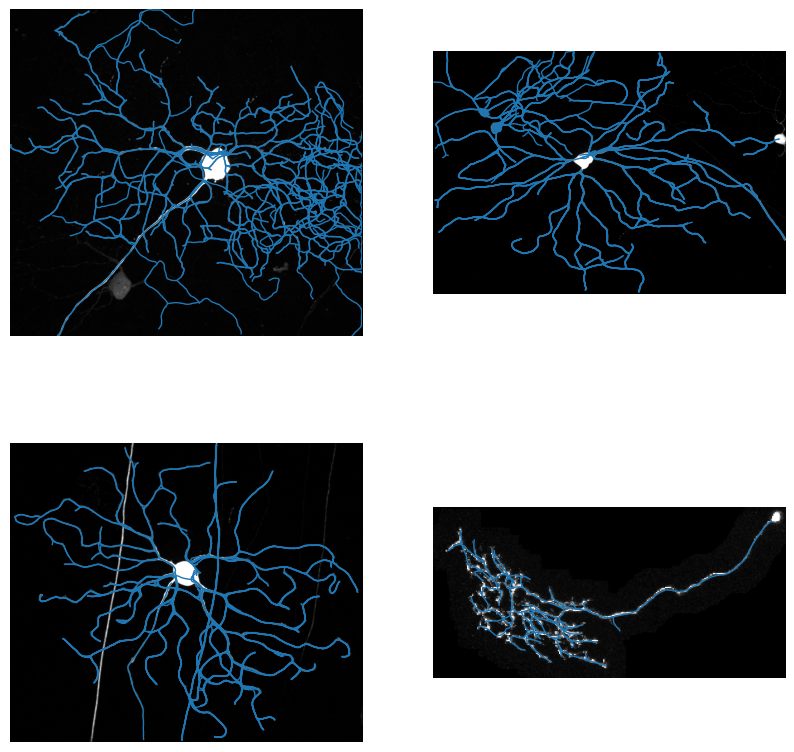

In [5]:
tif_paths = list(Path("../neurotrack_data/gold166_tifs_cropped_subset").glob("*.tif"))

plt.close('all')
fig, ax = plt.subplots(2,2, figsize=(10,10))
for i, result in enumerate(inference_payload['results'][:4]):
    tif_match = next((tif_path for tif_path in tif_paths if tif_path.stem == result['neuron_name']), None)
    img = tif.imread(tif_match) if tif_match else None
    if img is not None:
        ax[i // 2, i % 2].imshow(img[0].max(axis=0), cmap='gray')
        ax[i // 2, i % 2].axis('off')
    paths = result['paths']
    lines = collections.LineCollection([np.array(path)[:, :2] for path in paths], linewidths=1.0)
    ax[i // 2, i % 2].add_collection(lines)
plt.show()


## 2) Run Postprocessing

In [12]:
inference_results = list(inference_payload["results"])

postprocess_config = PostprocessConfig.from_config(config)

postprocessed_results = []
postprocessed_results = [
    r
    for result in inference_results
    for r in process_results(
        [result],
        postprocess_config.to_dict(),
    )
]
postprocess_out = write_processed_swc(postprocessed_results, out_dir)

print(f"postprocessed reconstructions are written to {postprocess_out['swc_out_dir']}")

print("postprocessed result keys:")
for k in postprocessed_results[0].keys():
    print(k)

Processing neuron '091204c2'
              Params
              ------
              enable_length_filter: False
              min_branch_length: 5.0
              max_branch_length: inf
              enable_resample: False
              resampling_step_size: 1.0
              enable_smooth_paths: False
              smoothing_window: 5
              enable_merge: True
              merge_threshold: 8.0
              confidence_threshold: 0
              merge_timeout_seconds: 30.0
              mask_smoothing_size: 0

    Initial paths count: 393, total nodes: 21593
    Restructuring paths...
    Merging overlapping paths...
    Merged 391 overlapping path(s) onto longer paths
    Merged paths count: 272
    Restructuring paths after merge...
Finished processing neuron '091204c2'

Processing neuron '140918c7'
              Params
              ------
              enable_length_filter: False
              min_branch_length: 5.0
              max_branch_length: inf
              enable

### Plot the processed results

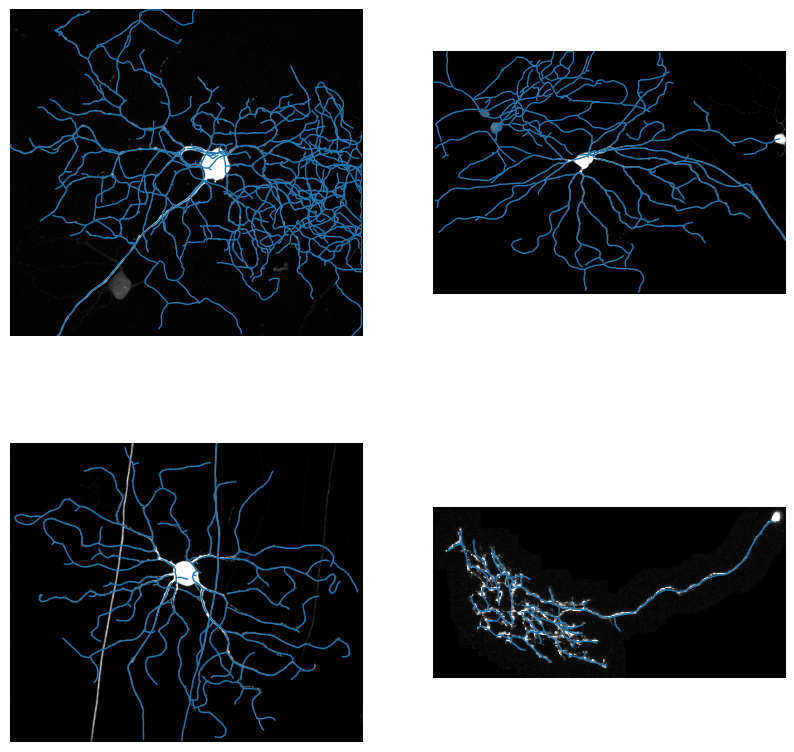

In [13]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
for i, result in enumerate(postprocessed_results[:4]):
    paths = result['processed_paths']
    tif_match = next((tif_path for tif_path in tif_paths if tif_path.stem == result['neuron_name']), None)
    img = tif.imread(tif_match) if tif_match else None
    if img is not None:
        ax[i // 2, i % 2].imshow(img[0].max(axis=0), cmap='gray')
        ax[i // 2, i % 2].axis('off')
    lines = collections.LineCollection([np.array(path)[:, :2] for path in paths], linewidths=1.0)
    ax[i // 2, i % 2].add_collection(lines)
plt.show()

## 3) Run Evaluation

In [14]:
evaluation_results = []

if len(postprocessed_results) > 0:
    evaluation_results = evaluate_postprocessed_results(
        postprocessed_results,
        swc_dir=config["swc_dir"],
        distance_threshold=float(config.get("distance_threshold", 2.0)),
    )

    metrics_csv = out_dir / f"{config['name']}_metrics.csv"
    save_evaluation_results(
        evaluation_results,
        str(metrics_csv),
        write_summary=False,
    )

pipeline_summary = compute_pipeline_summary(
    postprocessed_results=postprocessed_results,
    evaluation_results=evaluation_results,
    has_ground_truth=True,
)

pipeline_summary_path = out_dir / f"{config['name']}_summary.json"
with open(pipeline_summary_path, "w") as handle:
    json.dump(pipeline_summary, handle, indent=2)

skipped = pipeline_summary.get("skipped_neurons", [])
if skipped:
    print(f"\n[pipeline] {len(skipped)} neuron(s) skipped:")
    for entry in skipped:
        print(f"  - {Path(entry['neuron_name']).stem}: {entry['reason']}")
else:
    print(f"\n[pipeline] All {pipeline_summary.get('n_neurons', 0)} neurons processed successfully.")

print("Summary: {")
for key, value in pipeline_summary.items():
    print(f"  {key}: {value}")
print("}")
print(f"""
Summary path: {pipeline_summary_path},
Full output metrics saved to: {metrics_csv}

""")


[pipeline] All 4 neurons processed successfully.
Summary: {
  n_neurons: 4
  n_valid: 4
  n_skipped: 0
  skipped_neurons: []
  mean_bidirectional_distance: 14.55144752562046
  std_bidirectional_distance: 11.86660522359252
  median_bidirectional_distance: 13.576852142810822
  mean_directed_pred_to_gt: 26.507464677095413
  std_directed_pred_to_gt: 23.71686183828659
  mean_directed_gt_to_pred: 2.595430374145508
  std_directed_gt_to_pred: 0.2684333738009508
  mean_endpoint_localization_error: 31.177057036687685
  std_endpoint_localization_error: 20.965996316794833
  mean_branchpoint_localization_error: 31.449989360125873
  std_branchpoint_localization_error: 19.728043878532873
  mean_endpoint_count_error: 75.5
  std_endpoint_count_error: 65.44654307142586
  mean_branchpoint_count_error: 79.0
  std_branchpoint_count_error: 63.15457228103124
}

Summary path: test_trace_inference_output/test_example_inference_summary.json,
Full output metrics saved to: test_trace_inference_output/test_exampl